# Lab 6 Variant 6

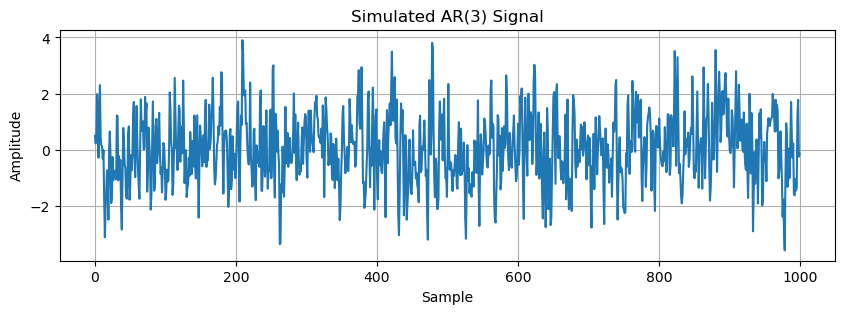

True AR coefficients (a1, a2, a3): [-0.75, 0.5, -0.3]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz
from statsmodels.regression.linear_model import yule_walker

# 1. Simulate AR(3) signal
N = 1000
np.random.seed(42)
w = np.random.normal(0, 1, N)
a_true = [1, -0.75, 0.5, -0.3]  # AR(3) coefficients: 1 - 0.75z^-1 + 0.5z^-2 - 0.3z^-3
ar_signal = lfilter([1], a_true, w)

plt.figure(figsize=(10, 3))
plt.plot(ar_signal)
plt.title("Simulated AR(3) Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print("True AR coefficients (a1, a2, a3):", a_true[1:])

In [2]:
# 2. Yule-Walker estimation
yw_coeffs, yw_sigma = yule_walker(ar_signal, order=3)
print("Yule-Walker estimated coefficients:", -yw_coeffs)
print("Yule-Walker noise variance:", yw_sigma)

Yule-Walker estimated coefficients: [-0.74008376  0.47158454 -0.26847661]
Yule-Walker noise variance: 0.97728650960135


In [3]:
# 3. Burg estimation
from spectrum import arburg

burg_coeffs, burg_sigma, _ = arburg(ar_signal, order=3)
print("Burg estimated coefficients:", burg_coeffs)
print("Burg noise variance:", burg_sigma)

Burg estimated coefficients: [-0.73917174+0.j  0.47007623+0.j -0.26828237+0.j]
Burg noise variance: 0.9569405255963549


In [4]:
# 4. Compare coefficients
print(f"{'':>12} {'a1':>10} {'a2':>10} {'a3':>10} {'sigma^2':>10}")
print(f"{'True':>12} {a_true[1]:>10.4f} {a_true[2]:>10.4f} {a_true[3]:>10.4f} {1.0:>10.4f}")
print(f"{'Yule-Walker':>12} {-yw_coeffs[0]:>10.4f} {-yw_coeffs[1]:>10.4f} {-yw_coeffs[2]:>10.4f} {yw_sigma:>10.4f}")
print(f"{'Burg':>12} {burg_coeffs[0].real:>10.4f} {burg_coeffs[1].real:>10.4f} {burg_coeffs[2].real:>10.4f} {burg_sigma:>10.4f}")

                     a1         a2         a3    sigma^2
        True    -0.7500     0.5000    -0.3000     1.0000
 Yule-Walker    -0.7401     0.4716    -0.2685     0.9773
        Burg    -0.7392     0.4701    -0.2683     0.9569


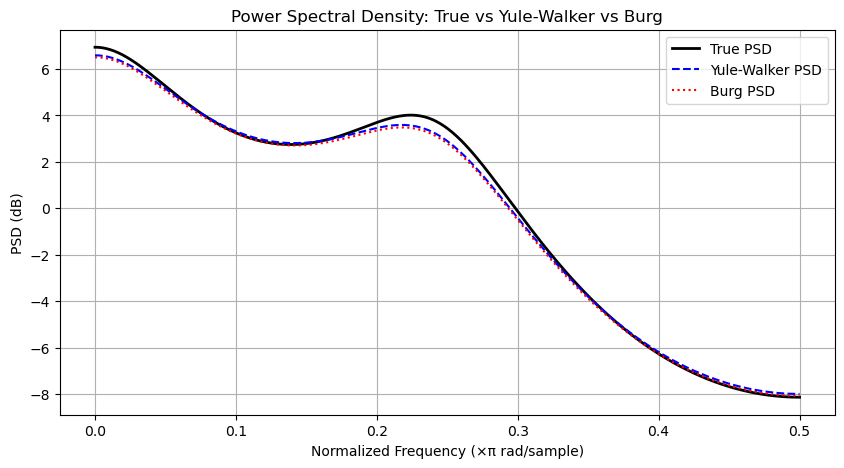

In [5]:
# 5. PSD comparison (frequency domain)
nfft = 1024
freqs = np.linspace(0, 0.5, nfft // 2 + 1)

# True PSD
_, h_true = freqz([1], a_true, worN=nfft, whole=True)
psd_true = 1.0 * np.abs(h_true[:nfft // 2 + 1]) ** 2

# Yule-Walker PSD
a_yw = np.concatenate(([1], -yw_coeffs))
_, h_yw = freqz([1], a_yw, worN=nfft, whole=True)
psd_yw = yw_sigma * np.abs(h_yw[:nfft // 2 + 1]) ** 2

# Burg PSD
a_burg = np.concatenate(([1], burg_coeffs))
_, h_burg = freqz([1], a_burg, worN=nfft, whole=True)
psd_burg = burg_sigma * np.abs(h_burg[:nfft // 2 + 1]) ** 2

plt.figure(figsize=(10, 5))
plt.plot(freqs, 10 * np.log10(psd_true), 'k-', linewidth=2, label='True PSD')
plt.plot(freqs, 10 * np.log10(np.abs(psd_yw)), 'b--', linewidth=1.5, label='Yule-Walker PSD')
plt.plot(freqs, 10 * np.log10(np.abs(psd_burg)), 'r:', linewidth=1.5, label='Burg PSD')
plt.xlabel("Normalized Frequency (×π rad/sample)")
plt.ylabel("PSD (dB)")
plt.title("Power Spectral Density: True vs Yule-Walker vs Burg")
plt.legend()
plt.grid(True)
plt.show()